In [2]:
import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from keras import layers
import openpyxl as xl
from openpyxl.styles import Font
import os

In [6]:
#Coletando dados

df = pd.read_excel('/Users/PC/Documents/Proj_MPA/Recontrucao/RJ/Crustaceos/RJ_Reconstrucao_Crustaceos_2024_08_02 (1).xlsx')



#Dados iniciais
df_especies = df[['Ano','TOTAL_GROUPS_F&M','TOTAL_CRUSTACEOS_F&M']]
inicio_pesca = pd.read_excel('/Users/PC/Documents/Proj_MPA/Recontrucao/RJ/Crustaceos/RJ_Crustaceos_Inicio_pesca_2024_06_21.xlsx')

lista_de_prop=[] #lista onde ficam os arrays com as proporções para cada especie
especies = df_especies.drop(['Ano','TOTAL_GROUPS_F&M'],axis=1).columns.to_numpy() #lista das especies

lista_de_anos_para_prever = []
lista_anos_com_dados = []

for k in range(len(especies)):

    dados = df_especies[['Ano',especies[k],'TOTAL_GROUPS_F&M']].dropna().reset_index(drop=True)
     
    #achando os anos para prever da especie
    anos_para_prever = []
    for i in range(len(inicio_pesca.iloc[:,0])):
        if inicio_pesca.loc[i,'Variavel'] == especies[k]:
            inicio = inicio_pesca.loc[i,'Ano_inicio']
            fim = inicio_pesca.loc[i,'Ano_final']
    anos = np.arange(inicio,fim+1)
    for i in anos:
        if pd.isnull(df_especies.loc[i-1950,especies[k]])==True:
            anos_para_prever.append(i)

    anos_para_prever = np.array(anos_para_prever)   
    print(anos_para_prever)
    lista_de_anos_para_prever.append(anos_para_prever)

    anos_com_dados = dados["Ano"].values
    lista_anos_com_dados.append(anos_com_dados)



    #Fazendo as proporções de cada especie em relação à soma
    for i in range(len(dados['Ano'])):
      if dados.loc[i,'TOTAL_GROUPS_F&M']!=0:
          dados.loc[i,'Prop_'+especies[k]] = dados.loc[i,especies[k]] / dados.loc[i,'TOTAL_GROUPS_F&M']
    
    
    anos_com_dados = dados["Ano"].values
    todos_anos = np.concatenate((anos_para_prever, anos_com_dados))
    todos_anos.sort()
    
    prop= dados['Prop_'+especies[k]].values
    lista_de_prop.append(prop)
    print(dados.head())



KeyError: 'Variavel'

In [ ]:
#Normalização dos dados
lista_ano_mean=[]
lista_ano_std=[]
lista_anos_com_dados_norm=[]
lista_de_anos_para_prever_norm=[]

lista_prop_norm=[]  #lista com as proporçãoes normalizads para cada especie
lista_prop_mean=[]  #listas para aplicar a inversa da normalização
lista_prop_std=[]

for k in range(len(lista_de_prop)):
    ano_mean = np.mean(lista_anos_com_dados[k])
    ano_std = np.std(lista_anos_com_dados[k])
    anos_para_prever_norm = (lista_de_anos_para_prever[k] - ano_mean)/ano_std
    anos_com_dados_norm = (lista_anos_com_dados[k] - ano_mean)/ano_std
    
    lista_anos_com_dados_norm.append(anos_com_dados_norm)
    lista_ano_mean.append(ano_mean)
    lista_ano_std.append(ano_std)
    lista_de_anos_para_prever_norm.append(anos_para_prever_norm)

    prop_mean = np.mean(lista_de_prop[k])
    prop_std = np.std(lista_de_prop[k])
    prop_norm = (lista_de_prop[k] - prop_mean)/prop_std

    lista_prop_norm.append(prop_norm)
    lista_prop_mean.append(prop_mean)
    lista_prop_std.append(prop_std)

print(lista_prop_norm)


[array([ 2.98063367,  2.38418969,  2.26237433,  0.61236924,  0.52822021,
        1.06507656,  0.10075462,  0.75794501,  0.06450562,  0.12466712,
        0.07546418,  0.11572012, -0.36422806, -1.24513825, -1.11043317,
       -1.03139153, -0.97122662, -0.37228467, -1.18494235, -0.99409241,
       -0.46361459, -0.10911199,  0.37722331, -0.16063824,  0.29566119,
       -0.04509998, -0.20093016,  1.55415179,  0.09239122,  0.5386173 ,
        0.92694467,  1.0185693 , -0.43324148,  0.19250408, -0.70492523,
        1.51460397,  0.20280274, -1.27251472, -0.92454892, -0.76687114,
       -0.61931918, -1.0618155 , -1.12486609, -0.75777973, -0.70902491,
       -1.15735103])]


In [ ]:
#Criação das pastas onde serão armazenados os pesos
for esp in especies:
    folder_path = f'C:\Users\PC\Documents\Proj_MPA\Recontrucao\RJ\Crustaceos\pesos prop {esp}'
    if not os.path.exists(folder_path):
        os.mkdir(folder_path) 


#Função para fazer o Fit do modelo e salvar seus pesos para cada especie
def Fit_das_proporcoes(anos_com_dados_norm,
                       lista_prop_norm,
                       lista_de_epocas,
                       lista_de_otimizadores,
                       lista_de_overwrite,
                       especies):
    
    model = keras.Sequential([layers.Dense(96,activation='leaky_relu',input_shape=(1,)),
                                 layers.Dense(32,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(80,activation='leaky_relu'),
                                 layers.Dense(96,activation='leaky_relu'),
                                 layers.Dense(112,activation='leaky_relu'),
                                 layers.Dense(1,activation='linear')])
    
    lista_de_loss=[]
    for k in range(len(especies)):
        opt =  lista_de_otimizadores[k]            #keras.optimizers.Nadam(learning_rate=0.001)
        model.compile(optimizer=opt, loss='mse')
        
        
        history = model.fit(anos_com_dados_norm,lista_prop_norm[k], epochs=lista_de_epocas[k], verbose=0)
        lista_de_loss.append(history.history['loss'])

        
        model.save_weights(f'C:\Users\PC\Documents\Proj_MPA\Recontrucao\RJ\Crustaceos/3. Extrapolações/pesos prop {especies[k]}/.weights.h5', overwrite=lista_de_overwrite[k])
    return model,lista_de_loss

In [ ]:
#Fit do modelo
Nadam= keras.optimizers.Nadam(learning_rate=0.001)
Adam= keras.optimizers.Adam(learning_rate=0.001)

lista_de_epocas=[100]
lista_de_otimizadores=[Adam]
lista_de_overwrite = [True]
model,lista_de_loss = Fit_das_proporcoes(anos_com_dados_norm,
                                         lista_prop_norm,
                                         lista_de_epocas,
                                         lista_de_otimizadores,
                                         lista_de_overwrite,
                                         especies)

/home/andre/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#Previsões para cada especie
lista_de_previsoes=[]
lista_fits=[]

p = np.linspace(-2,2,50)
for k in range(len(especies)):
    
    model.load_weights(f'C:\Users\PC\Documents\Proj_MPA\Recontrucao\RJ\Crustaceos/3. Extrapolações/pesos prop {especies[k]}/.weights.h5')

    prev_ausentes = model.predict(anos_para_prever_norm)*lista_prop_std[k] + lista_prop_mean[k]
    fit = model.predict(p)*lista_prop_std[k] + lista_prop_mean[k]
    #Colocando valores negativos para 0 e proporções no maximo 1
    for i in range(len(prev_ausentes)):
        if prev_ausentes[i]<0:
            prev_ausentes[i]=0
        if prev_ausentes[i]>1:
            prev_ausentes[i]=1

    lista_de_previsoes.append(prev_ausentes)
    lista_fits.append(fit)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


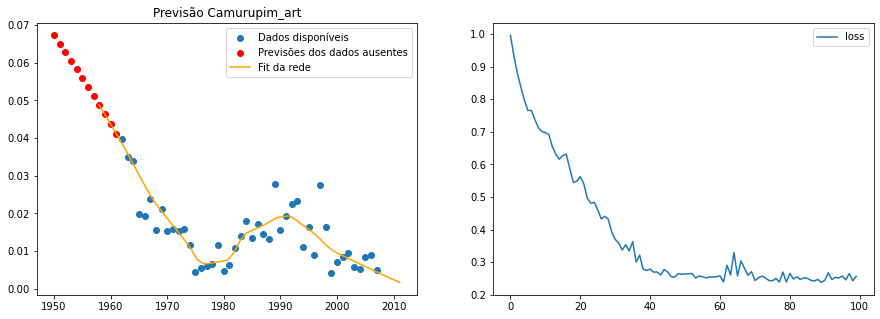

In [ ]:
#Plot das previsoes e loss para cada especie
for k in range(len(especies)):
    plt.figure(figsize=(15,5*len(especies)))
    plt.subplot(len(especies),2,2*k+1 ).scatter(anos_com_dados,lista_de_prop[k],label='Dados disponíveis')
    plt.subplot(len(especies),2,2*k+1 ).scatter(anos_para_prever,lista_de_previsoes[k], color='red', label='Previsões dos dados ausentes')
    plt.subplot(len(especies),2,2*k+1 ).plot(p*ano_std + ano_mean,lista_fits[k],color='orange',label='Fit da rede')
    plt.title(f'Previsão {especies[k]}')
    plt.legend()

    plt.subplot(len(especies),2,2*k+2).plot(lista_de_loss[k],label='loss')
    plt.legend()

plt.show()

In [ ]:
#Lista de anos sem buracos normalizada e sua predição      (para poder me referir por indices)
anos = np.arange(1950,np.max(anos_para_prever)+1)
anos_norm = (anos-ano_mean)/ano_std

#Previsoes sem buracos para cada especie
lista_prev_continua=[]
for k in range(len(especies)):
    model.load_weights(f'/home/andre/Área de Trabalho/Reconstrução da Estatística Pesqueira BR/Ceará/Albuliformes&Elopiformes/3. Extrapolações/pesos prop {especies[k]}/.weights.h5')
    prev_continua = model.predict(anos_norm)*lista_prop_std[k] + lista_prop_mean[k]
    
    for i in range(len(prev_continua)):
        if prev_continua[i]<0:
            prev_continua[i]=0
        if prev_continua[i]>=1:
            prev_continua[i]=1
    
    lista_prev_continua.append(prev_continua.flatten())
  


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [ ]:
#Dicionario dos indices das espécie para prever e da que será desagregada
especies_com_desagregada = np.append(especies,'TOTAL_GROUPS_F&M') 
todas_colunas=df.columns.to_numpy()
dic_especies={}
for k in range(len(especies_com_desagregada)):
    for i in range(len(todas_colunas)):
        if especies_com_desagregada[k]==todas_colunas[i]:
            dic_especies[especies_com_desagregada[k]]=i+1 #Índices do openpyxl
            break
print(dic_especies)

{'Camurupim_art': 2, 'TOTAL_FISHES_F&M': 9}


In [ ]:
#Adicionando novos dados na planilha e colorindo
wb = xl.load_workbook('/home/andre/Área de Trabalho/Reconstrução da Estatística Pesqueira BR/Ceará/Albuliformes&Elopiformes/2. Interpolações/Interpolações.xlsx')
ws=wb.active

for k in range(len(especies)):
    for i in range(len(anos)):
        celula=ws.cell(anos[i]-1950+2 , dic_especies[especies[k]])
        
        #Dados desagregados para células com valores mantém a cor
        if i+1950 in anos_para_prever and pd.isnull(celula.value)==False:   
          celula.value += ws.cell(anos[i]-1950+2, dic_especies['TOTAL_GROUPS_F&M']).value*lista_prev_continua[k][i]
          celula.font = Font(color=celula.font.color,name='Calibri')


        #Dados desagregados para celulas vazias são colocados em vermelho
        if i+1950 in anos_para_prever and pd.isnull(celula.value)==True:
          celula.value = ws.cell(anos[i]-1950+2, dic_especies['TOTAL_GROUPS_F&M']).value*lista_prev_continua[k][i]
          celula.font = Font(color='FFFF0000',name='Calibri')
          

      

wb.save('Extrapolações com proporção.xlsx')

In [ ]:
   ###Caso o openpyxl não coloque todos os valores###



df_prev = df[['Ano','Bandeirado_art','Cambeua_art','Cangata_art','Gurijuba_art','Uritinga_art','Jurupiranga_art','Uriacica_art']]
for k in range(len(especies)):
    for i in range(len(anos)):
        if anos[i] in lista_de_anos_para_prever[k]:
            df_prev.loc[anos[i]-1950,especies[k]] = df_especies.loc[anos[i]-1950,'TOTAL_GROUPS_F&M']*lista_prev_continua[k][i]
df_prev.to_excel('Extrapol pandas.xlsx')
